In [2]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import os
import time
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS
from uuid import uuid4
from langchain_core.documents import Document
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
import pandas as pd
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from typing import List, TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import START, StateGraph
import dateparser
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8364\1570484257.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.docstore.in_memory import InMemoryDocstore


True

In [3]:
# Simpan API key di: Colab Secrets (🔑) → nama secret: GEMINI
GEMINI = os.getenv("GEMINI_API_KEY")
os.environ["GOOGLE_API_KEY"] = GEMINI

In [42]:
# text-embedding-004 adalah model embedding terbaru dari Google menghasilkan vector 768 dimensi per teks
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview", output_dimensionality=768)

# Convert each row to Document chunks
documents = []

splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1500,
    chunk_overlap=200
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [43]:
df = pd.read_csv("pidato_presiden.csv")
# df = df.head(5)

contents = "\n\n".join(df["content"].tolist())
chunks = splitter.split_text(contents)
print(f"Total chunks: {len(chunks)}")

# Generate UUID untuk setiap dokumen
uuids = [str(uuid4()) for _ in range(len(chunks))]

Created a chunk of size 6790, which is longer than the specified 1500
Created a chunk of size 1637, which is longer than the specified 1500
Created a chunk of size 1689, which is longer than the specified 1500
Created a chunk of size 2194, which is longer than the specified 1500
Created a chunk of size 1534, which is longer than the specified 1500
Created a chunk of size 2268, which is longer than the specified 1500
Created a chunk of size 1765, which is longer than the specified 1500
Created a chunk of size 1871, which is longer than the specified 1500
Created a chunk of size 3365, which is longer than the specified 1500
Created a chunk of size 14735, which is longer than the specified 1500
Created a chunk of size 2000, which is longer than the specified 1500
Created a chunk of size 2181, which is longer than the specified 1500
Created a chunk of size 1815, which is longer than the specified 1500
Created a chunk of size 1598, which is longer than the specified 1500
Created a chunk of 

Total chunks: 453


In [25]:
# Preview setiap chunk (100 karakter pertama saja)
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk[:100]}...")

Chunk 1: Sabtu, 23 Mei 2026Di baca 23 kali
DiDesa Tegalretno, Kecamatan Petanahan, Kabupaten Kebumen, Jawa Te...
Chunk 2: Assalamu’alaikum warahmatullahi wabarakatuh,Salam sejahtera kepada kita sekalian,Syalom,Salve,Om swa...
Chunk 3: Sabtu, 23 Mei 2026
Rabu, 20 Mei 2026
Senin, 18 Mei 2026
Sabtu, 16 Mei 2026
Sabtu, 16 Mei 2026
Copyri...
Chunk 4: Yang saya hormati Wakil Presiden Republik Indonesia, Saudara Gibran Rakabuming Raka;Yang saya hormat...
Chunk 5: Alhamdulillahirabbil’alamin, puji syukur kita panjatkan ke hadirat Allah Swt. atas rahmat dan hidaya...
Chunk 6: Saudara-saudara sekalian,saya telah disumpah oleh Saudara-saudara sekalian, di hadapan Saudara-sauda...
Chunk 7: Saudara-saudara sekalian,sekarang izinkanlah saya menyampaikan angka-angka kunci dari Kerangka Ekono...
Chunk 8: Dengan strategi ekonomi yang tepat, kebijakan fiskal yangprudentdan berkelanjutan, saya yakin ekonom...
Chunk 9: Kita juga akan membuka lapangan kerja secara besar-besaran. Ditargetkan proporsi lapang

In [44]:
# Inisialisasi FAISS baru untuk dokumen PDF ini
index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [45]:
# Bungkus setiap chunk sebagai Document object
documents = [Document(page_content=chunk) for chunk in chunks]

# Generate UUID untuk setiap dokumen
uuids = [str(uuid4()) for _ in range(len(documents))]

# Embed dan simpan ke FAISS
for idx in range(len(documents)):
    vector_store.add_documents(documents=[documents[idx]], ids=[uuids[idx]])
    
print(f"{len(documents)} chunks berhasil disimpan ke vector store")

453 chunks berhasil disimpan ke vector store


In [47]:
# Simpan ke disk agar tidak perlu embed ulang
vector_store.save_local("faiss_index")
print("Index tersimpan di folder faiss_index/")

Index tersimpan di folder faiss_index/


In [48]:
DB_FAISS_PATH = r"D:\Portofolio\chatbot\know_your_president\faiss_index"
vector_store = FAISS.load_local(
    DB_FAISS_PATH, 
    embeddings, 
    allow_dangerous_deserialization=True
)

In [30]:
from langchain_core.documents import Document
from typing import List, TypedDict
from langchain_groq import ChatGroq

# State adalah "tas" yang dibawa sepanjang perjalanan graph
# Setiap node bisa membaca dan mengisi field di State
class State(TypedDict):
    question: str           # pertanyaan dari user
    context: List[Document] # hasil retrieve dari FAISS
    answer: str             # jawaban final dari LLM

In [31]:
from langchain_core.prompts import ChatPromptTemplate

# Define the strict prompt template
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a strict, factual assistant. Your ONLY task is to answer the user's question "
        "using exclusively the provided Context below. You must adhere to the following rules:\n\n"
        "1. Direct Reliance: Rely only on clear and directly mentioned facts in the context. "
        "Do not assume, extrapolate, or bring in outside knowledge.\n"
        "2. Strict Boundary: If the answer cannot be fully and completely found within the provided context, "
        "you must state exactly: 'I cannot answer this based on the provided context.' Do not attempt to "
        "provide a partial or guessed answer.\n"
        "3. No Fluff: Be concise, direct, and factual. Avoid any speculation.\n\n"
        "--- CONTEXT ---\n"
        "{context}\n"
        "----------------"
    ),
    (
        "human",
        "{question}"
    )
])

In [33]:
# Inisialisasi LLM — pakai Llama 3.3 70B via Groq (gratis, cepat)
# Groq menyediakan inference engine yang sangat cepat untuk model open-source

GROQ = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ

MODEL = 'llama-3.3-70b-versatile'

llm = ChatGroq(
    temperature=0,  # 0 = deterministik, cocok untuk Q&A faktual
    model=MODEL     # bisa diganti model lain seperti gemini atau GPT
)

In [34]:
# Node 1: Retrieve — ambil dokumen relevan dari FAISS
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


# Node 2: Generate — buat jawaban berdasarkan context + question
def generate(state: State):
    # Gabungkan semua chunk yang diambil jadi satu string konteks
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    # Isi template prompt dengan konteks dan pertanyaan
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    # Kirim ke LLM
    response = llm.invoke(messages)
    return {"answer": response.content}

In [35]:
from langgraph.graph import START, StateGraph

# Definisikan graph: retrieve dulu, lalu generate
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

print("Graph berhasil dikompilasi!")

Graph berhasil dikompilasi!


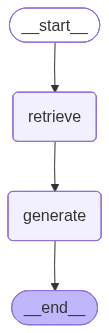

In [36]:
# Visualisasi alur graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
result = graph.invoke({"question": "Poin apa saja yang menjadi fokus presiden Indonesia?"})

print("=== Context yang diambil dari FAISS ===")
for i, doc in enumerate(result["context"]):
    print(f"\nChunk {i+1}:")
    print(doc.page_content[:200] + "...")

print("\n=== Jawaban LLM ===")
print(result["answer"])

=== Context yang diambil dari FAISS ===

Chunk 1:
Dengan strategi ekonomi yang tepat, kebijakan fiskal yangprudentdan berkelanjutan, saya yakin ekonomi Indonesia dapat tumbuh pada kisaran 5,8 hingga 6,5 persen di tahun 2027, menuju pertumbuhan ekonom...

Chunk 2:
Saudara-saudara sekalian,saya telah disumpah oleh Saudara-saudara sekalian, di hadapan Saudara-saudara sekalian, dan di hadapan rakyat. Tugas saya untuk menjalankan Undang-Undang Dasar Negara Republik...

Chunk 3:
Saudara-saudara,saya kalau keluar negeri sebagai Presiden Indonesia, saya sangat dihormati sekarang, sangat dihormati. Bahkan mereka sekarang banyak negara minta bantuan ke kita. Mereka minta bantuan ...

Chunk 4:
Untuk itu, saya di hadapan majelis yang terhormat ini, di hadapan seluruh rakyat Indonesia, saya ingatkan bahwa saya pernah disumpah di sini untuk menjalankan Undang-Undang Dasar 1945 dengan segala pe...

=== Jawaban LLM ===
Presiden Indonesia memiliki beberapa fokus, yaitu:

1. Meningkatkan pertumbuhan eko